# **2. Problem Statement**
### **You are an ML Engineer at a tech company. Your task is to build, train, and evaluate a machine learning model that predicts an outcome from real-world data. You must compare at least 3 different ML algorithms, evaluate them using proper metrics, and clearly explain which model performed best and why.**

### **Import required libraries**

In [281]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

###**Load the dataset**

In [282]:
df = pd.read_csv('/content/heart.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### **Shape of the dataset**

In [283]:
df.shape

(1025, 14)

### **Type of data**

In [284]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


### **Checking for duplicate values**

In [285]:
df.duplicated().sum()

np.int64(723)

### **Handling duplicate values**

In [286]:
df = df.drop_duplicates()

In [287]:
df.duplicated().sum()

np.int64(0)

In [288]:
df.shape

(302, 14)

### **Check Null Values**

In [289]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### **Checking Columns**

| Column   |  | Why                                          |
| -------- | --------- | -------------------------------------------- |
| age      |          | Risk factor for heart disease                |
| sex      |          | Gender-related risk differences              |
| cp       |          | Chest pain type is highly predictive         |
| trestbps |          | Blood pressure affects heart health          |
| chol     |          | Cholesterol is a major risk factor           |
| fbs      |          | Blood sugar level may indicate diabetes risk |
| restecg  |          | ECG results provide cardiac information      |
| thalach  |          | Maximum heart rate achieved                  |
| exang    |          | Exercise-induced angina is important         |
| oldpeak  |          | Indicates heart stress during exercise       |
| slope    |          | ECG slope information                        |
| ca       |          | Number of major vessels observed             |
| thal     |          | Thalassemia test result                      |
| target   |          | Target variable                              |



In [290]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [291]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [292]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0
878,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


## **Verifying the Outliers**

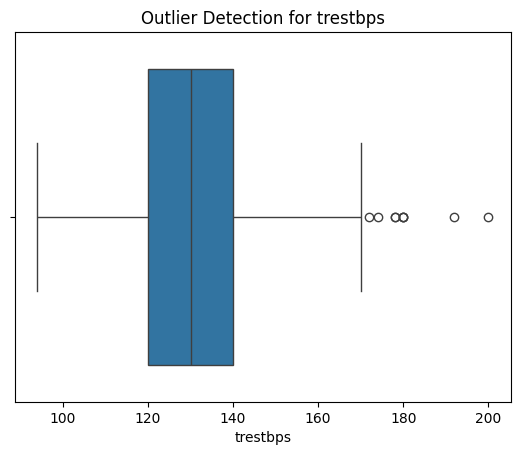

In [293]:
# trestbps
sns.boxplot(df, x='trestbps')
plt.title('Outlier Detection for trestbps')
plt.show()

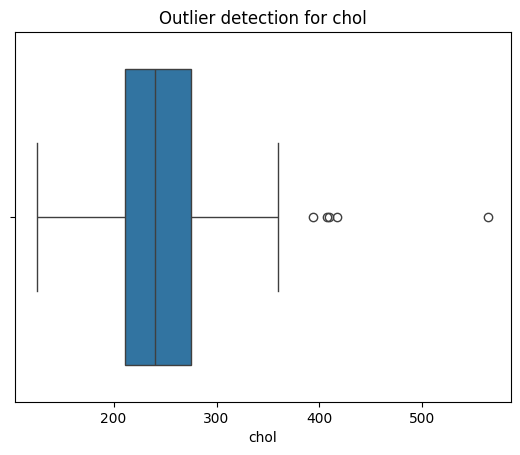

In [294]:
# chol
sns.boxplot(df, x='chol')
plt.title('Outlier detection for chol')
plt.show()

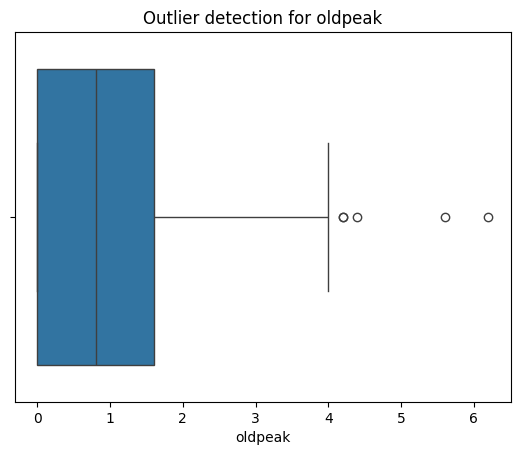

In [295]:
# oldpeak
sns.boxplot(df, x='oldpeak')
plt.title('Outlier detection for oldpeak')
plt.show()

### **Observation**
* **Outlier analysi**s was performed using **Boxplots**.
* A **small no. of outliers** were identified in the variables **trestbps**, **chol**, and **oldpeak**.
* Since these values are medically plausible and may represent high-risk patients, they were retained to preserve important clinical information and **avoid loss of valuable patterns**.



## **Selecting the Target Variable.**
* According to the problem statement, **target** is the **target variable**.
* The **target** column was selected as the **dependent variable** because it represents the **presence or absence of heart disease**.
* target columns says
  * 0 - No Heart Disease
  * 1 - Heart Disease Present
* All remaining columns were used as predictor variables for model training.
* As the **target variable** is **available**, it is **Supervised** Machine learning Model.
* It means it can be either Regression or Classification depending upon the data type of the target variable.
* Since the target has only two possible values 0, 1 this is a **Binary Classification** Problem.

In [296]:
# Let us select the target variable
# y = Output Variable / Dependent Variable / Target Variable
y = df['target']
y.shape

(302,)

In [297]:
# Let us select input variable
# X = Input variable / Independent Variable / Predictors
X = df.drop(columns='target')
X.shape

(302, 13)

## **Splitting data into Train and Test Data.**
* For this we use **sklearn** library.
* Let us import train and test from sklearn.

In [298]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

* Let us verify the shape of train and test datasets.

In [299]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(241, 13)
(61, 13)
(241,)
(61,)


### **Observations**
* The dataset was split into training and testing sets using an 80:20 ratio.
* The **training set (80%)** is used to train the machine learning models
* The **testing set (20%)** is used to evaluate model performance on unseen data.

## **Feature Scaling**

In [300]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

X_train_trans = ss.fit_transform(X_train)
X_test_trans = ss.transform(X_test)

X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns)
X_test_trans = pd.DataFrame(X_test_trans, columns=X_test.columns)

In [301]:
X_train_trans.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.831130,-1.445595,-0.901724,0.518128,0.517982,-0.405279,-1.008059,0.474526,-0.704907,2.151696,-2.179312,1.247972,-0.516003
1,1.054184,0.691757,1.056073,0.518128,1.914986,-0.405279,0.875214,0.388540,-0.704907,-0.871970,0.975128,-0.717788,-0.516003
2,0.385022,-1.445595,2.034972,1.083912,0.830744,2.467435,-1.008059,0.560511,-0.704907,-0.032063,0.975128,-0.717788,-0.516003
3,-1.287882,-1.445595,-0.901724,0.065500,2.040091,2.467435,-1.008059,-0.557300,1.418626,1.647751,-0.602092,-0.717788,1.142088
4,-1.622463,0.691757,-0.901724,-1.179227,-1.587949,-0.405279,-1.008059,-1.503141,1.418626,0.807844,-0.602092,-0.717788,1.142088


In [302]:
X_test_trans.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-1.733989,0.691757,-0.901724,-0.726599,-0.503707,-0.405279,0.875214,-0.385329,-0.704907,0.135919,-0.602092,-0.717788,1.142088
1,0.385022,0.691757,1.056073,-1.462120,-0.065840,-0.405279,-1.008059,0.216569,1.418626,-0.368026,-0.602092,-0.717788,1.142088
2,-0.284139,0.691757,0.077175,0.178657,-0.879021,-0.405279,0.875214,0.388540,-0.704907,-0.200044,0.975128,0.265092,-0.516003
3,-1.399409,0.691757,2.034972,0.970755,0.017563,-0.405279,-1.008059,1.248395,-0.704907,-0.200044,0.975128,1.247972,-0.516003
4,1.054184,-1.445595,-0.901724,2.781267,1.706478,-0.405279,0.875214,0.216569,1.418626,-0.871970,0.975128,-0.717788,-0.516003


<Axes: xlabel='thalach', ylabel='Density'>

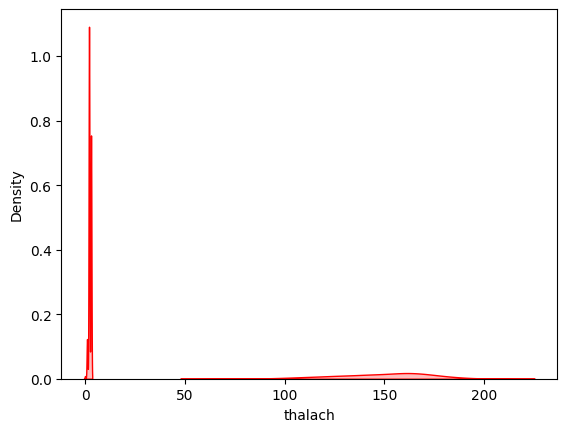

In [303]:
sns.kdeplot(X_train, x='thalach', color='red', fill=True)
sns.kdeplot(X_train, x='thal', color='red', fill=True)


<Axes: xlabel='thalach', ylabel='Density'>

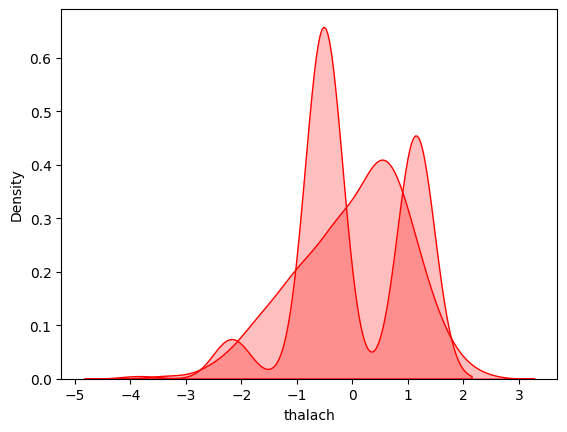

In [304]:
sns.kdeplot(X_train_trans, x='thalach', color='red', fill=True)
sns.kdeplot(X_train_trans, x='thal', color='red', fill=True)


<Axes: xlabel='sex', ylabel='Density'>

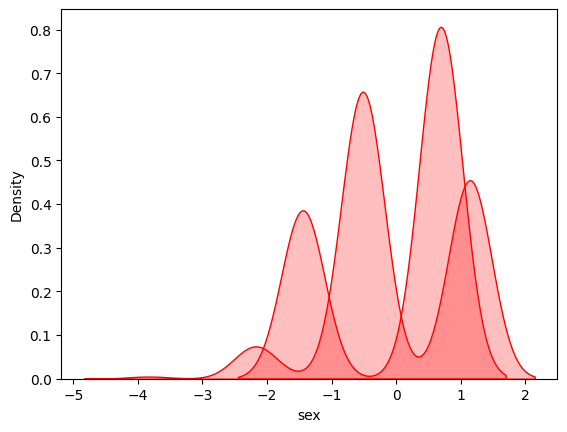

In [305]:
sns.kdeplot(X_train_trans, x='sex', color='red', fill=True)
sns.kdeplot(X_train_trans, x='thal', color='red', fill=True)

## **Feature Selection**
### **Observation**
* Here, feature selection is not necessary.
* Feature selection is usually performed when:
  * There are too many features (50, 100, 1000+ columns)
  * Some columns are irrelevant (ID, Name, Address, Email, etc.)
  * Features are highly redundant
  * The model is overfitting
* But, All of them are:
  * Clinically meaningful
  * Commonly used in heart disease prediction
  * Not identifier columns

Therefore, there is no reason to remove features.

## **Model Selection**
#### **1. Logistic Regression**
**Why Selected?**

* It is one of the most **widely used algorithms** for **binary classification**.
* It **predicts the probability** of belonging to a class.

**Observation**

* Logistic Regression was chosen because it **performs well** when the relationship between features and the target is approximately **linear**.
* It also helps understand how individual medical factors influence heart disease prediction.

#### **2. K-Nearest Neighbors (KNN)**
**Why Selected?**
* KNN is a **distance-based algorithm**.
* It makes predictions based on similar patients in the dataset.
* It does not assume any underlying relationship between variables.

**Observation**

* KNN was selected to evaluate how well a similarity-based learning approach performs on the heart disease dataset.
* Since patients with similar medical characteristics may have similar outcomes, KNN provides an alternative prediction strategy compared to Logistic Regression.

#### **3. Random Forest**
**Why Selected?**

* Random Forest is an ensemble learning algorithm.
* It combines multiple decision trees.
* It captures complex and non-linear relationships.
* It is robust to noise and overfitting.

**Observation**

* Random Forest was selected because medical datasets often contain complex interactions among variables.
* The ensemble approach allows Random Forest to capture these patterns more effectively than individual models.

### **Why Not Other Models?**
**Decision Tree**

* Random Forest is an improved version of Decision Tree.
* It generally provides better accuracy and stability.

**Linear Regression**
* Linear Regression is designed for continuous numerical outputs.
* Your target variable is categorical (0 or 1).
* Therefore, Linear Regression is not suitable for this classification problem.

**SVM**
* SVM is a powerful classification algorithm.
* However, it requires more parameter tuning and computational effort.
* Logistic Regression, KNN, and Random Forest provide a good mix of simple, distance-based, and ensemble learning approaches.

## **Model Training**
### **Step-1: Baseline Evaluation Using Cross Validation**
### **1. Train Logistic Regression for Binary Classification**


In [306]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(max_iter=1000)

lr_scores = cross_val_score(
    lr,
    X_train_trans,
    y_train,
    cv=5,
    scoring='recall'
)

print("Logistic Regression Recall Scores:")
print(lr_scores)
print("Average Recall:", lr_scores.mean())

Logistic Regression Recall Scores:
[0.81481481 0.80769231 0.84615385 0.96153846 0.84615385]
Average Recall: 0.8552706552706553


## **2. Train KNN**

In [307]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn_scores = cross_val_score(
    knn,
    X_train_trans,
    y_train,
    cv=5,
    scoring='recall'
)

print("KNN Recall Scores:")
print(knn_scores)
print("Average Recall:", knn_scores.mean())

KNN Recall Scores:
[0.81481481 0.80769231 0.88461538 0.96153846 0.88461538]
Average Recall: 0.8706552706552706


## **3. Train Random Forest**

In [308]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print("Random Forest Recall Scores:")
print(rf_scores)
print("Average Recall:", rf_scores.mean())

Random Forest Recall Scores:
[0.81481481 0.80769231 0.84615385 0.96153846 0.92307692]
Average Recall: 0.8706552706552706


## **Step-2: Hyperparameter Tuning**

### **Logistic Regression Tuning**

In [309]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring='recall'
)

lr_grid.fit(X_train_trans,y_train)

print("Best Parameters:",lr_grid.best_params_)
print("Best Recall:",lr_grid.best_score_)

Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best Recall: 0.9162393162393162


### **KNN Tuning**

In [310]:
knn_params = {
    'n_neighbors':[3,5,7,9,11],
    'weights':['uniform','distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='recall'
)

knn_grid.fit(X_train_trans,y_train)

print("Best Parameters:",knn_grid.best_params_)
print("Best Recall:",knn_grid.best_score_)

Best Parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best Recall: 0.8777777777777779


### **Random Forest Tuning**

In [311]:
rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='recall'
)

rf_grid.fit(X_train,y_train)

print("Best Parameters:",rf_grid.best_params_)
print("Best Recall:",rf_grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best Recall: 0.8786324786324787


## **Step-3: Compare Tuned Models**

In [312]:
results = pd.DataFrame({
    'Model':['Logistic Regression','KNN','Random Forest'],
    'Best Recall':[
        lr_grid.best_score_,
        knn_grid.best_score_,
        rf_grid.best_score_
    ]
})

results.sort_values(
    by='Best Recall',
    ascending=False
)

,Model,Best Recall
0,Logistic Regression,0.916239
2,Random Forest,0.878632
1,KNN,0.877778


## **Model Evaluation for all 3 models**

In [313]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get the best estimators from GridSearchCV results
best_lr = lr_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Make predictions on the test set
y_pred_lr = best_lr.predict(X_test_trans)
y_pred_knn = best_knn.predict(X_test_trans)
y_pred_rf = best_rf.predict(X_test)

print('Comparision for 3 models')
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf)
    ]
})

results.sort_values(by='Recall', ascending=False)

Comparision for 3 models


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.756098,0.939394,0.837838
1,KNN,0.803279,0.769231,0.909091,0.833333
2,Random Forest,0.836066,0.810811,0.909091,0.857143




## **Key Observations**

### **Observation 1: Random Forest is the Best Overall Model**

After hyperparameter tuning:

* Highest Accuracy = **83.61%**
* Highest Precision = **81.08%**
* Highest F1 Score = **85.71%**

This indicates that Random Forest provides the best overall balance between correctly identifying heart disease patients and minimizing prediction errors.


### **Observation 2: Logistic Regression Has the Highest Recall**

* Recall = **93.94%**

* Out of all patients who actually have heart disease, Logistic Regression correctly identifies approximately **94 out of every 100 patients**.

* For healthcare applications, Recall is usually the most important metric because:

```text
False Negative = Patient has heart disease
                 but model predicts healthy
```

* Missing a patient is generally more dangerous than raising a false alarm.


### **Observation 3: Random Forest Has the Highest Precision**

* Precision = **81.08%**

* When Random Forest predicts that a patient has heart disease, it is correct more often than the other models.

* This means Random Forest produces fewer false positive predictions while still maintaining a high Recall of **90.91%**.


### **Observation 4: KNN Delivered Moderate Performance**

* Accuracy = **80.33%**
* Recall = **90.91%**
* F1 Score = **83.33%**

KNN achieved competitive results but was slightly outperformed by Random Forest across most evaluation metrics. This suggests that distance-based classification works reasonably well for this dataset but is not the optimal choice.


## **Which Model is Final?**

### **Select: Random Forest**

Random Forest achieved:

* Accuracy = **83.61%**
* Precision = **81.08%**
* Recall = **90.91%**
* F1 Score = **85.71%**

Although Logistic Regression achieved a slightly higher Recall (**93.94%**), Random Forest delivered the best overall performance by achieving the highest Accuracy, Precision, and F1 Score. Therefore, **Random Forest was selected as the final model for heart disease prediction.**


### **Confusion Matrix for Random Forest**

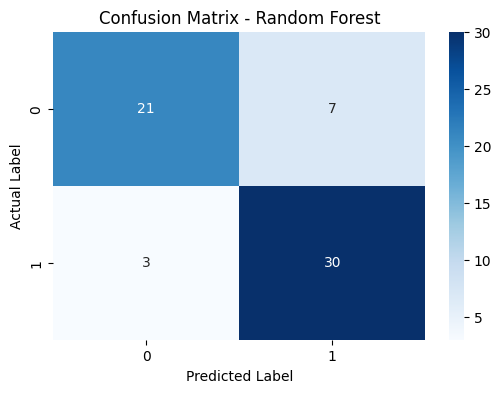

In [316]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()



## **Why Random Forest Performed Better**

* Random Forest achieved the highest **Accuracy (83.61%)**, indicating that it correctly classified the largest number of patients among all models.
* It achieved the highest **Precision (81.08%)**, meaning its positive predictions were more reliable and produced fewer false alarms.
* Random Forest also achieved the highest **F1 Score (85.71%)**, demonstrating the best balance between Precision and Recall.
* Although Logistic Regression achieved a slightly higher Recall (93.94%), Random Forest maintained a strong Recall of **90.91%** while outperforming all other models in overall predictive performance.
* Cross-validation and hyperparameter tuning enhanced the model's robustness and helped it generalize well to unseen data, making it the most reliable model for heart disease prediction.
